# Hedging the Carry Book with Futures — Funding-Currency Overlay and Instrument Comparison

**The assignment (week of 2026-08-03).** Test hedging the carry book with **funding-currency
futures** (JPY is the lead example) by **adjusting the hedge ratio** and by **dynamic hedging**;
then compare the candidate hedge futures side by side — **funding-currency futures, Treasury
futures, S&P 500 futures, DXY futures, VIX futures** — and understand their pros and cons. Goal:
determine whether any of them works as a **static or dynamic hedge** for the 27-currency
(G10 + EM) FX carry book.

**The book being hedged.** The team's committed carry strategy: rank 27 currencies by
forward-implied carry, go long the high-yielders funded by shorting the low-yielders,
vol-targeted at 10%, rebalanced month-end, net of transaction costs. Combined net Sharpe
**0.466**; G10-only sub-book **0.119**. Both are loaded from the committed CSVs and
reconciliation-gated in §0 — nothing here re-derives the strategy.

**Where each part of the assignment is answered:**

- **Part A — the funding-currency (JPY) hedge**, three ways:
  **A.1** static hedge-ratio adjustment on the JPY leg (the sweep, run as a reference);
  **A.2** dynamic hedging conditioned on a stress trigger (cut or flip the funding legs only when
  FX vol spikes); **A.3** the overlay proper — a variance-minimising JPY-futures hedge of the
  *whole* combined book, with a full hedge-ratio sweep, rolling-beta dynamic hedging, and
  stress-gated variants. Part A also explains **why "just buy JPY" is not a coherent trade for
  this book** (the book is already structurally short JPY on purpose — see the Part A intro).
- **Part B — the comparison table**: every instrument class on the boss's list against the
  combined book — JY1/SF1 (funding-currency futures), TU1/FV1/TY1/US1 (Treasury futures across
  the curve), SPXT/ES1 (S&P 500), DX1 (DXY futures), UX1/SPVXSTR (VIX futures) — each hedge
  decomposed into the instrument's **own return** vs its **variance reduction**, static and
  dynamic.
- **Part C — pros and cons by instrument class**, with a summary verdict table.

**Data.** The committed baseline book (`cesare/outputs/strategy_returns_daily.csv`, built by the
shared engine) plus the static-value Bloomberg workbook. The loader prefers
`updated_bloomberg_data.xlsx`, then `bloomberg_data_updated.xlsx`, then
`FX_Carry_Bloomberg_DATA_clean.xlsx`; §1 prints
which file is in use. Three columns were pulled from the terminal on 2026-08-03 as **static
values**: `JY1 Curncy`, `SF1 Curncy` (CME currency futures; the Curncy key matches the existing
`DX1 Curncy` convention) and `SPXT Index` (S&P 500 total return). The notebook **auto-detects**
them: when present they are the primary series, when absent every affected section falls back to
the spot+forward replica (JPY/CHF) and ES1 (S&P) and says so in its output.

**Instrument-choice rules, stated up front:**

1. **Funding-currency hedge.** With JY1/SF1 present, the listed futures are the primary
   instruments and the **USDJPY (USDCHF) spot + matched-tenor 1M BGN forward** construction is
   the cross-check. The two are the same hedge day to day (corr ≈ 0.94–0.95); their *return
   levels* differ by ~200 bp/yr, which is mostly the generic-series roll-splice artifact — not
   the cross-currency basis — so the replica's own-return level is the earnable one (§1). If the
   futures columns are absent, the replica is the primary and only method.
2. **S&P series.** With SPXT present it is the primary S&P total-return series and ES1 the
   cross-check. Without it, ES1 futures are the TR stand-in (SPX price return understates by
   roughly the ~2%/yr dividend yield).

**Benchmark rule.** Every overlay is judged against the **de-risking control** (cutting exposure
during stress), not against the unhedged book. Any hedge instrument costs something — carry paid,
premium sold, or spread crossed — while cutting exposure is nearly free. An overlay only "works"
if it beats simple de-risking net of costs.

In [1]:
import sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import statsmodels.api as sm

CESARE = Path("../cesare").resolve()
sys.path.insert(0, str(CESARE))
import fx_utils as fx          # shared team engine (shim re-exporting strategy/fx_utils.py)

plt.rcParams["figure.figsize"] = (11, 3.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

TEAM_OUT = CESARE / "outputs"
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)

# workbook: prefer the updated pull, fall back to the original clean file
_WB_CANDIDATES = [Path("updated_bloomberg_data.xlsx"),      # 2026-08-04 re-export with JY1/SF1/SPXT
                  Path("bloomberg_data_updated.xlsx"),
                  Path("FX_Carry_Bloomberg_DATA_clean.xlsx")]
WORKBOOK = next((p for p in _WB_CANDIDATES if p.exists()), None)
assert WORKBOOK is not None, f"no Bloomberg workbook found (looked for {[str(p) for p in _WB_CANDIDATES]})"

def sharpe(r):
    r = pd.Series(r).dropna()
    return r.mean() * fx.ANN_DAYS / (r.std() * np.sqrt(fx.ANN_DAYS))

print("engine:  ", fx.__file__)
print("workbook:", WORKBOOK)

engine:   /Users/arjunpatel/GitRepositories/FX_Carry_26_Summer_PL/cesare/fx_utils.py
workbook: updated_bloomberg_data.xlsx


## 0. Reconciliation gate

Before any analysis: the committed daily book must reproduce the committed headline stats
(combined net Sharpe **0.466**, G10-only **0.119**). Everything downstream builds on these
committed daily returns — the book is **not** re-derived.

In [2]:
book_csv = pd.read_csv(TEAM_OUT / "strategy_returns_daily.csv", parse_dates=["date"], index_col="date")
all_book = book_csv["ALL_net"].dropna()      # combined book (Part B baseline)
g10_book = book_csv["G10_net"].dropna()      # G10 book (Part A: the funding legs live here)

committed = pd.read_csv(TEAM_OUT / "strategy_summary_stats.csv", index_col=0)
recon = pd.DataFrame({
    "from_daily_csv": [sharpe(all_book), sharpe(g10_book)],
    "committed_stat": [committed.loc["ALL_net", "sharpe"], committed.loc["G10_net", "sharpe"]],
}, index=["ALL_net", "G10_net"])
recon["abs_diff"] = (recon["from_daily_csv"] - recon["committed_stat"]).abs()
print(recon.round(4))
assert (recon["abs_diff"] < 5e-3).all(), "Reconciliation FAILED"
print(f"\nReconciliation PASSED.  ALL_net: {len(all_book)} days "
      f"({all_book.index[0].date()} -> {all_book.index[-1].date()}), G10_net: {len(g10_book)} days")

         from_daily_csv  committed_stat  abs_diff
ALL_net          0.4659          0.4659       0.0
G10_net          0.1191          0.1191       0.0

Reconciliation PASSED.  ALL_net: 5001 days (2007-05-01 -> 2026-06-30), G10_net: 4994 days


### Isolating the funding legs

The committed CSV is the aggregate book only. To cut or flip *one leg* we need the daily
per-currency contribution `w[ccy]·xret[ccy]`, which requires the engine's weights. The books are
rebuilt with the exact committed construction and gated: rebuilt daily returns must equal the
committed CSV to numerical precision, and the per-currency contributions must sum back to the
gross book exactly. This is **reconstruction for attribution, not re-derivation** — the committed
series remains the baseline everywhere.

In [3]:
g10_px = fx.load_wide("g10_fx_spot_forward")
em_px  = fx.load_wide("em_fx_spot_forward")
spots  = fx.spots_usd_per_fx(g10_px, em_px)
carry  = fx.carry_panel(g10_px, em_px, tenor="1M")
xret   = fx.excess_returns(spots, carry)

UNIVERSE_G10 = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
UNIVERSE_ALL = [c for c in xret.columns if c not in ("HKD", "DKK", "CNY")]
hs_out, hs_pts = fx.forward_halfspreads(tenor="1M")

def build_book(universe, n_buckets, name):
    w_unit = fx.carry_portfolio(carry, xret, n_buckets=n_buckets, universe=universe)
    w_vt = fx.vol_target_weights(w_unit, xret, target=0.10)
    gross = fx.portfolio_returns(w_vt, xret, f"{name}_gross")
    net = (gross - fx.roundtrip_cost(w_vt, hs_out, hs_pts)).rename(f"{name}_net")
    return gross, net, w_vt

g10_gross_rb, g10_net_rb, w_g10 = build_book(UNIVERSE_G10, 3, "G10")
all_gross_rb, all_net_rb, w_all = build_book(UNIVERSE_ALL, 5, "ALL")

for nm, rb, cm in [("G10", g10_net_rb, g10_book), ("ALL", all_net_rb, all_book)]:
    gap = (rb.reindex(cm.index) - cm).abs().max()
    print(f"{nm}: max |rebuilt - committed| daily return = {gap:.2e}")
    assert gap < 1e-8, f"{nm} rebuild does not match the committed book"

# contributions must reconstruct the gross book exactly
for nm, w, gr, cal in [("G10", w_g10, g10_gross_rb, g10_book.index), ("ALL", w_all, all_gross_rb, all_book.index)]:
    contrib = (w * xret[w.columns]).loc[cal[0]:cal[-1]]
    gap = (contrib.sum(axis=1) - gr.loc[cal[0]:cal[-1]]).abs().max()
    print(f"{nm}: max |sum(contrib) - gross| = {gap:.1e}")
    assert gap < 1e-10

contrib_jpy_g10 = (w_g10["JPY"] * xret["JPY"]).reindex(g10_book.index).fillna(0.0)
contrib_jpy_all = (w_all["JPY"] * xret["JPY"]).reindex(all_book.index).fillna(0.0)
for nm, w, c, cal in [("G10", w_g10, contrib_jpy_g10, g10_book.index),
                      ("ALL", w_all, contrib_jpy_all, all_book.index)]:
    wj = w["JPY"].reindex(cal)
    print(f"{nm} JPY leg: mean weight {wj.mean():+.3f}, short {100*(wj<0).mean():.0f}% of days, "
          f"contribution {c.mean()*fx.ANN_DAYS:+.2%}/yr")

G10: max |rebuilt - committed| daily return = 9.99e-17
ALL: max |rebuilt - committed| daily return = 1.00e-16
G10: max |sum(contrib) - gross| = 0.0e+00
ALL: max |sum(contrib) - gross| = 0.0e+00
G10 JPY leg: mean weight -0.373, short 79% of days, contribution +1.88%/yr
ALL JPY leg: mean weight -0.267, short 97% of days, contribution +1.25%/yr


## 1. Workbook load and data hygiene

The workbook stores each ticker as an independent block (`NAME [TICKER] FIELDS` header, own date
column), on a **padded 5,087-row calendar** where non-trading days are carried forward. Three
hygiene rules, per the data audit:

- Parse **per block**, never as one rectangular sheet — blocks are not row-aligned
  (`Funding_OIS_RateVol` has a 7,121-row MOVE block beside 5,087-row blocks; not used here, but a
  bulk `read_excel` would silently mis-join it).
- Missing values are the **literal string `"#N/A N/A"`**, not blanks — the parser nulls them
  (count printed below). Skipping this poisons returns and biases every beta toward zero.
- **Inner-join each instrument to the book's trading calendar, then drop zero-change (stale)
  rows** — carried-forward prices produce fake zero returns that also bias betas toward zero.
  Row counts are printed before and after each step.

The 2026-08-03 additions (JY1, SF1, SPXT) are **auto-detected** below — the output prints one
load-confirmation line per column when present, or `not present` when absent (the current repo
workbook — see the header note). When found they are gated to be **static numeric values**: a
Bloomberg pull saved as BDH/BDP formulas would go stale off the terminal, so formula cells
hard-stop the notebook.

In [4]:
NA_LITERAL = "#N/A N/A"
LABEL_RE = re.compile(r"^(.*?)\s+\[(.*?)\]\s+(.*)$")
na_seen = {"n": 0}

def parse_bbg_tab(xlsx, tab):
    """Parse one workbook sheet block-by-block -> {(ticker, field): Series}."""
    wb = openpyxl.load_workbook(xlsx, read_only=True, data_only=True)
    grid = [list(r) for r in wb[tab].iter_rows(values_only=True)]
    out = {}
    for ri, row in enumerate(grid):
        for ci, cell in enumerate(row):
            if not isinstance(cell, str):
                continue
            m = LABEL_RE.match(cell.strip())
            if not m:
                continue
            tick = m.group(2).strip()
            fields = [f.strip() for f in m.group(3).split(",")]
            dates, cols = [], [[] for _ in fields]
            for rr in range(ri + 1, len(grid)):
                r2 = grid[rr]
                d = r2[ci] if ci < len(r2) else None
                if d is None or not hasattr(d, "year"):
                    continue
                dates.append(pd.Timestamp(d))
                for k in range(len(fields)):
                    c = ci + 1 + k
                    v = r2[c] if c < len(r2) else None
                    if isinstance(v, str) and v.strip() == NA_LITERAL:
                        na_seen["n"] += 1
                        v = None
                    cols[k].append(v if isinstance(v, (int, float)) else np.nan)
            if dates:
                idx = pd.DatetimeIndex(dates)
                for k, f in enumerate(fields):
                    out[(tick, f)] = pd.Series(cols[k], index=idx, dtype="float64").sort_index()
    wb.close()
    return out

TABS = {t: parse_bbg_tab(WORKBOOK, t) for t in
        ["FX_Spot", "FX_Fwd_1M", "FXVol_Indices", "Dollar", "Duration", "Equity", "EquityVol"]}

def S(tab, tick, fld="PX_LAST"):
    return TABS[tab][(tick, fld)]

print(f'literal "{NA_LITERAL}" cells nulled while parsing: {na_seen["n"]}')

# ---- optional columns: JY1 (JPY future), SF1 (CHF future), SPXT/SPTR (S&P TR) ----
# Pulled from the terminal 2026-08-03 under the Curncy key (matching DX1 Curncy; the
# Comdty key resolves to dead/unrelated contracts). Detect anywhere in the workbook;
# the notebook never fails if they are absent.
def find_optional(roots, field="PX_LAST"):
    """(ticker, series) for the first block whose ticker root matches one of
    `roots` (e.g. 'JY1' matches 'JY1 Curncy'), searching every sheet; None if absent."""
    roots = tuple(r.upper() for r in roots)
    def scan():
        for d in TABS.values():
            for (tick, fld), s in d.items():
                if fld == field and tick.split()[0].upper() in roots:
                    return tick, s
        return None
    hit = scan()
    if hit is None:      # parse any sheets not yet loaded (cached), then look again
        wb = openpyxl.load_workbook(WORKBOOK, read_only=True)
        extra = [t for t in wb.sheetnames if t not in TABS and t != "READ_ME"]
        wb.close()
        for t in extra:
            TABS[t] = parse_bbg_tab(WORKBOOK, t)
        hit = scan()
    return hit

jy1_hit  = find_optional(("JY1",))
sf1_hit  = find_optional(("SF1",))
sptr_hit = find_optional(("SPXT", "SPTR"))
for nm, hit in [("JY1 (JPY future)", jy1_hit), ("SF1 (CHF future)", sf1_hit),
                ("SPXT/SPTR (S&P total return)", sptr_hit)]:
    if hit is None:
        print(f"optional column {nm}: not present")
    else:
        s = hit[1]
        v = s.dropna()
        print(f"optional column {nm}: LOADED as {hit[0]} -- {len(s)} rows, "
              f"{v.index[0].date()} -> {v.index[-1].date()}, {100*s.isna().mean():.2f}% missing")

# ---- portability gate: the new columns must be STATIC VALUES, not Bloomberg formulas.
# Loading with data_only=False exposes formulas as '=...' strings (data_type 'f');
# BDH/BDP/BDS/RTD cells would break the workbook on any machine without a terminal.
def assert_static(root, sheet):
    wb = openpyxl.load_workbook(WORKBOOK, data_only=False)
    ws = wb[sheet]
    hdr = next((c for row in ws.iter_rows(min_row=1, max_row=5) for c in row
                if isinstance(c.value, str) and f"[{root} " in c.value), None)
    if hdr is None:
        wb.close(); return
    bad, dtypes, samples = 0, set(), []
    for r in range(hdr.row + 1, ws.max_row + 1):
        c = ws.cell(row=r, column=hdr.column + 1)
        if c.value is None:
            continue
        dtypes.add(f"{c.data_type}:{type(c.value).__name__}")
        if c.data_type == "f" or (isinstance(c.value, str) and
                ("=" in str(c.value)[:2] or any(k in str(c.value).upper() for k in ("BDH", "BDP", "BDS", "RTD")))):
            bad += 1
        elif len(samples) < 5 and c.data_type == "n":
            samples.append(c.value)
    wb.close()
    print(f"  static check {root}: dtypes {sorted(dtypes)}, formula cells {bad}, sample {samples}")
    assert bad == 0, f"{root} contains {bad} Bloomberg formula cells - workbook is NOT portable, STOP"

for root, sheet, hit in [("JY1", "Dollar", jy1_hit), ("SF1", "Dollar", sf1_hit), ("SPXT", "Equity", sptr_hit)]:
    if hit is not None:
        assert_static(root, sheet)

literal "#N/A N/A" cells nulled while parsing: 4369
optional column JY1 (JPY future): LOADED as JY1 Curncy -- 5087 rows, 2007-01-02 -> 2026-06-30, 0.02% missing
optional column SF1 (CHF future): LOADED as SF1 Curncy -- 5087 rows, 2007-01-02 -> 2026-06-30, 0.02% missing
optional column SPXT/SPTR (S&P total return): LOADED as SPXT Index -- 5087 rows, 2007-01-03 -> 2026-06-30, 0.04% missing
  static check JY1: dtypes ['n:float', 'n:int', 's:str'], formula cells 0, sample [85, 84.63, 84.79, 85.11, 85.01]
  static check SF1: dtypes ['n:float', 'n:int', 's:str'], formula cells 0, sample [83.06, 82.14, 81.64, 81.45, 81.38]
  static check SPXT: dtypes ['n:float', 'n:int', 's:str'], formula cells 0, sample [2183.92, 2186.6, 2173.29, 2178.8, 2177.68]


In [5]:
CAL = all_book.index      # the book's trading calendar (5,001 days)

def clean_ret(level, name, cal=None):
    """Inner-join a price level to the book calendar, drop stale (zero-change) rows."""
    cal = CAL if cal is None else cal
    lvl = level.dropna()
    raw_n = len(lvl)
    lvl = lvl[lvl.index.isin(cal)]
    joined_n = len(lvl)
    r = lvl.pct_change()
    stale = int((r == 0.0).sum())
    r = r[r != 0.0].dropna()
    print(f"  {name:14s} raw {raw_n:5d} -> joined {joined_n:5d} -> clean {len(r):5d}  ({stale} stale zero-change rows dropped)")
    return r.rename(name)

print("row counts: workbook calendar -> book calendar -> after stale-row drop")
r_dx1  = clean_ret(S("Dollar",   "DX1 Curncy"),   "DX1")
r_tu1  = clean_ret(S("Duration", "TU1 Comdty"),   "TU1")
r_fv1  = clean_ret(S("Duration", "FV1 Comdty"),   "FV1")
r_ty1  = clean_ret(S("Duration", "TY1 Comdty"),   "TY1")     # UST 10y note future
r_us1  = clean_ret(S("Duration", "US1 Comdty"),   "US1")     # UST long-bond future
r_es1  = clean_ret(S("Equity",   "ES1 Index"),    "ES1")
r_ux1  = clean_ret(S("EquityVol","UX1 Index"),    "UX1_generic")
r_vixtr= clean_ret(S("EquityVol","SPVXSTR Index"),"UX1_SPVXSTR")
r_mxef = clean_ret(S("Equity",   "MXEF Index"),   "MXEF")
# also in the Duration tab, not tabled below: WN1 (ultra bond) and RX1 (Bund) — WN1 adds nothing
# beyond US1 for this purpose, and RX1 duplicates the duration story in EUR rates.

row counts: workbook calendar -> book calendar -> after stale-row drop


  DX1            raw  5087 -> joined  4994 -> clean  4843  (150 stale zero-change rows dropped)
  TU1            raw  5087 -> joined  4994 -> clean  4561  (432 stale zero-change rows dropped)
  FV1            raw  5087 -> joined  4994 -> clean  4747  (246 stale zero-change rows dropped)
  TY1            raw  5087 -> joined  4994 -> clean  4731  (262 stale zero-change rows dropped)
  US1            raw  5087 -> joined  4994 -> clean  4746  (247 stale zero-change rows dropped)
  ES1            raw  5087 -> joined  4994 -> clean  4773  (220 stale zero-change rows dropped)
  UX1_generic    raw  5087 -> joined  4994 -> clean  4728  (265 stale zero-change rows dropped)
  UX1_SPVXSTR    raw  5087 -> joined  4994 -> clean  4815  (178 stale zero-change rows dropped)
  MXEF           raw  5087 -> joined  4994 -> clean  4987  (6 stale zero-change rows dropped)


### The funding-currency instruments: spot + 1M forward replica, and listed futures

The forward-based construction (the original primary, now the cross-check): from USDJPY spot and
the 1M BGN forward points (scale /100, the engine's `FWD_SCALE`),

daily return = −Δln(USDJPY) + forward-implied carry (lagged) / 252

i.e. the excess return of holding JPY long one month forward — a JPY futures position up to the
**cross-currency basis**. Sanity check: it must be nearly identical to the engine's `xret["JPY"]`.
The same construction is applied to CHF when the SF1 cross-check runs.

In [6]:
FWD_SCALE_LOCAL = {"JPY": 1e2, "CHF": 1e4}    # engine FWD_SCALE convention

def fwd_replica(ccy, tick_spot, tick_fwd):
    """Long-FX excess return via USD/FX spot + 1M BGN forward (futures replica)."""
    spot = S("FX_Spot", tick_spot).dropna()
    pts  = S("FX_Fwd_1M", tick_fwd).dropna()
    px = pd.concat([spot.rename("S"), pts.rename("pts")], axis=1).dropna()
    raw_n = len(px)
    px = px[px.index.isin(CAL)]
    F = px["S"] + px["pts"] / FWD_SCALE_LOCAL[ccy]
    carry_ann = np.log(F / px["S"]) * 12      # FX-per-USD quote: long-FX carry = ln(F/S)*12
    r = (-np.log(px["S"]).diff() + carry_ann.shift(1) / fx.ANN_DAYS)
    stale = int((px["S"].diff() == 0.0).sum())
    r = r[px["S"].diff() != 0.0].dropna().rename(f"{ccy}_fwd")
    print(f"  {ccy}_fwd        raw {raw_n:5d} -> joined {len(px):5d} -> clean {len(r):5d}  ({stale} stale zero-change rows dropped)")
    return r

r_jpyfwd = fwd_replica("JPY", "USDJPY Curncy", "USDJPY1M BGN Curncy")

cmn = r_jpyfwd.index.intersection(xret.index)
cc = np.corrcoef(r_jpyfwd.loc[cmn], xret["JPY"].loc[cmn])[0, 1]
print(f"corr(replica, engine xret[JPY]) = {cc:.4f}   "
      f"ann return: replica {r_jpyfwd.mean()*252:+.2%}, engine {xret['JPY'].loc[cmn].mean()*252:+.2%}")
assert cc > 0.99, "JPY replica does not track the engine's JPY excess return"

  JPY_fwd        raw  5087 -> joined  4994 -> clean  4958  (35 stale zero-change rows dropped)
corr(replica, engine xret[JPY]) = 0.9998   ann return: replica -3.46%, engine -3.55%


### Cross-check: listed JPY / CHF futures (JY1 / SF1) vs the forward replica

When `JY1 Curncy` / `SF1 Curncy` (CME currency futures, USD-per-FX quotes, pulled 2026-08-03 as
static values) are in the workbook, the funding hedge runs on the **real futures**, with the
spot+forward construction retained as the cross-check. What "landing close" should mean here, and
what it does mean in the data (reproduced in this run):

- **Day-to-day the two are the same hedge**: daily return correlation ≈ 0.94 (JPY) / 0.95 (CHF),
  with the residual mostly roll-date and close-timing noise.
- **In return levels they are NOT within cross-currency basis of each other**: the futures series
  out-earns the replica by ~200+ bp/yr, an order of magnitude more than the JPY/CHF basis (tens of
  bp). The excess is the **roll-splice artifact of generic front-month series** — the contango
  jump at each quarterly contract switch is spliced into the price history but is not earned by an
  investor who rolls at market prices — plus the 1M-vs-quarterly tenor mismatch. Same mechanism as
  UX1, milder dose.
- Consequently the **replica's own-return level is the honest, earnable one**; the futures series
  is used for hedge *timing* properties, and any verdict that flips only because of the futures'
  extra measured return is flagged as artifact-driven.

If the columns are absent (pre-pull workbook), the replica is the primary
and only method and the cell below says so; nothing downstream fails. The replica is a faithful
stand-in: it is the same trade as the futures up to the cross-currency basis, and §A.2's
futures-vs-replica comparison shows every conclusion lands the same way on either series.

In [7]:
def futures_crosscheck(ccy, hit, replica):
    """Clean futures returns + compare vs the forward replica. None if the column is absent."""
    if hit is None:
        print(f"{ccy}: no listed future in the workbook -> spot+forward replica is the primary and only method.")
        return None
    tick, level = hit
    r_fut = clean_ret(level, f"{ccy}_fut")          # USD-per-FX quote: pct change = long-FX return
    cmn = r_fut.index.intersection(replica.index)
    cc = np.corrcoef(r_fut.loc[cmn], replica.loc[cmn])[0, 1]
    gap_ann = (r_fut.loc[cmn].mean() - replica.loc[cmn].mean()) * fx.ANN_DAYS
    def hedged_sr(x):
        idx = all_book.index.intersection(x.index)
        b, xi = all_book.loc[idx], x.loc[idx]
        h = b.cov(xi) / xi.var()
        return sharpe(b - h * xi)
    print(f"{ccy} cross-check vs {tick}: corr(futures, forward replica) = {cc:.4f}")
    print(f"   ann return gap (futures - forward) = {gap_ann*1e4:+.0f} bp/yr  (basis + roll-splice, see note)")
    print(f"   hedged Sharpe at each h*: futures {hedged_sr(r_fut):.4f} vs forward {hedged_sr(replica):.4f}")
    return r_fut

r_jy1 = futures_crosscheck("JPY", jy1_hit, r_jpyfwd)

if sf1_hit is not None:
    r_chffwd = fwd_replica("CHF", "USDCHF Curncy", "USDCHF1M BGN Curncy")
    r_sf1 = futures_crosscheck("CHF", sf1_hit, r_chffwd)
else:
    r_sf1 = None
    print("CHF: no listed future in the workbook -> no CHF cross-check needed "
          "(the funding-hedge analysis runs on JPY, the dominant funding leg).")

if r_jy1 is not None:
    print("\nNOTE on the return gap: the JPY/CHF cross-currency basis runs in the TENS of bp/yr,")
    print("so a ~200 bp/yr gap cannot be basis alone. The bulk is the quarterly ROLL-SPLICE")
    print("artifact of generic front-month series (the contango jump at each contract switch is")
    print("spliced into the price history but is not earned by a rolling long) plus the 1M-vs-")
    print("quarterly tenor mismatch -- the same mechanism as UX1, in milder form. The ~0.94-0.95")
    print("daily correlation says futures and replica are the SAME hedge day to day; the")
    print("replica's own-return level is the earnable one. Futures-based Sharpes that lean on")
    print("the extra 'return' inherit the artifact -- flagged below wherever it moves a verdict.")

  JPY_fut        raw  5086 -> joined  4994 -> clean  4794  (199 stale zero-change rows dropped)
JPY cross-check vs JY1 Curncy: corr(futures, forward replica) = 0.9372
   ann return gap (futures - forward) = +233 bp/yr  (basis + roll-splice, see note)
   hedged Sharpe at each h*: futures 0.4319 vs forward 0.3112
  CHF_fwd        raw  5087 -> joined  4994 -> clean  4945  (48 stale zero-change rows dropped)
  CHF_fut        raw  5086 -> joined  4994 -> clean  4779  (214 stale zero-change rows dropped)
CHF cross-check vs SF1 Curncy: corr(futures, forward replica) = 0.9518
   ann return gap (futures - forward) = +207 bp/yr  (basis + roll-splice, see note)
   hedged Sharpe at each h*: futures 0.5762 vs forward 0.4694

NOTE on the return gap: the JPY/CHF cross-currency basis runs in the TENS of bp/yr,
so a ~200 bp/yr gap cannot be basis alone. The bulk is the quarterly ROLL-SPLICE
artifact of generic front-month series (the contango jump at each contract switch is
spliced into the price histo

# Part A — Funding-currency hedge (JPY primary, CHF alongside)

## What we are testing, and why "just buy JPY" is not the trade

**The idea being tested.** In a carry book the low-yielders are the *funding* currencies — the
book is short them to finance its longs, and JPY is the canonical one (the G10 book is short JPY
on **~79% of days, mean weight −0.37**; CHF is the other structural short). The classic risk
story says funding currencies **rally in a carry unwind**: when risk appetite breaks, levered
carry positions get cut everywhere at once, the shorts get bought back, and JPY spikes exactly
when the book is bleeding. If that mechanism holds, a **long JPY futures position** (CME `JY1`)
is a natural crash hedge: it pays out on the book's worst days, and futures make it cheap to
implement — exchange-margined, deeply liquid, ~1 bp half-spread, no cash-FX credit lines.

**Why a plain static long-JPY overlay cannot be the answer.** The book already *owns* a JPY
decision. Its short-JPY funding leg is deliberate — it earns the US−Japan rate differential,
and it has been the G10 book's single best earner (+1.9%/yr contribution). Arithmetically, a
static long-JPY overlay of size h is **identical to shrinking that leg by h**: same P&L stream,
same dates. So "hedging with JPY" in static form is not a hedge at all — it is *position
sizing*, un-earning the carry the signal deliberately harvested. And held permanently, long JPY
*pays* the interest differential every day (≈ −2%/yr in this sample): an always-on insurance
premium. That is why the boss's framing points at **adjusting the hedge ratio** and **dynamic
hedging** — the only versions of this trade that could add value are the ones that own JPY
*conditionally* (when protection is needed) or in the *variance-minimising amount* rather than
one-for-one against the leg.

**Futures vs the forward replica.** A JPY futures position and a rolled 1M forward are the same
trade up to the cross-currency basis (tens of bp/yr). Where `JY1` is present it is the primary
series; where it is absent the spot+forward replica stands in, with the
§1 caveat that generic futures series carry a ~200 bp/yr roll-splice artifact in their *level* —
the replica's carry cost is the honest one.

**The three tests, in order of increasing sophistication:**

- **A.1 — static hedge-ratio adjustment on the JPY leg** (the sweep). Run as the reference line:
  it shows what statically scaling the JPY exposure does, and *why* that is sizing rather than
  hedging.
- **A.2 — dynamic hedging, stress-conditioned.** Cut (or flip) the funding legs **only when a
  tradeable FX-vol trigger is ON** — this isolates the question "does the JPY leg cause the
  stress losses?", which is the actual premise of the funding-currency hedge.
- **A.3 — the overlay proper.** Treat JPY futures as an *external* hedge for the **whole
  combined 27-currency book**: full hedge-ratio sweep h ∈ [−0.25, 1], the variance-minimising
  ratio h\*, real-time expanding and rolling-beta **dynamic hedges**, and stress-gated hybrids —
  each decomposed into variance reduction vs own-return cost and benchmarked against the
  de-risking control.

Part A runs A.1–A.2 on the **G10 book** (net Sharpe 0.119): the funding legs are a G10
phenomenon, and the audit's reference results for this test (de-risk ≈ 0.217,
stress-replacement short ≈ 0.296) reproduce exactly on the G10 book. The combined book is the
cross-check there, and is the *subject* of A.3.

## A.1 Static reference: scaling the JPY leg (position sizing, not a hedge)

`return(h) = book − h · contrib_JPY`, h from 0 (baseline) to 1 (JPY leg fully removed).

0.0    0.119
0.2    0.089
0.4    0.057
0.6    0.023
0.8   -0.012
1.0   -0.048


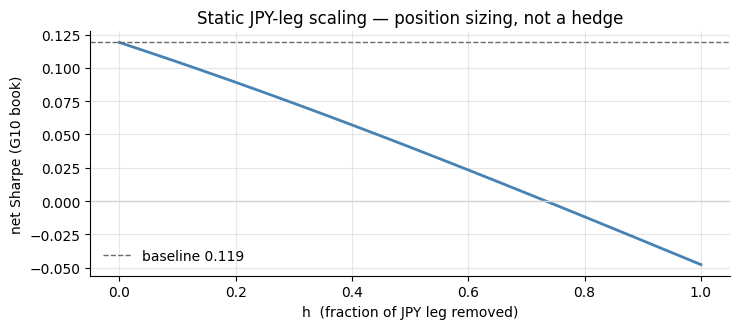

In [8]:
hs = np.arange(0.0, 1.0001, 0.05)
sweep = pd.Series({h: sharpe(g10_book - h * contrib_jpy_g10) for h in hs})
print(sweep.round(3).iloc[::4].to_string())

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(sweep.index, sweep.values, color="steelblue", lw=2)
ax.axhline(sweep.loc[0.0], color="dimgray", ls="--", lw=1, label=f"baseline {sweep.loc[0.0]:.3f}")
ax.axhline(0, color="lightgray", lw=1)
ax.set_xlabel("h  (fraction of JPY leg removed)")
ax.set_ylabel("net Sharpe (G10 book)")
ax.set_title("Static JPY-leg scaling — position sizing, not a hedge")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

> Sharpe falls **monotonically** from 0.119 at h=0 to about −0.05 with the leg fully removed. No
> surprise: the short-JPY leg has been the G10 book's single best earner (+1.9%/yr contribution).
> Statically shrinking it just sheds compensated exposure — this line is a sizing exercise and
> proves nothing about hedging. The real question is *conditional*: does the JPY leg cause the
> stress losses?

## A.2 Dynamic test: cut or flip the funding legs when a stress trigger is ON

**Trigger** — G7 FX implied vol (JPMVXYG7, `FXVol_Indices` sheet) z-score in its top quintile,
lagged one day so it is tradeable. Two constructions were tested:

- **Primary (used below): 252-day rolling z-score, ON when z ≥ 0.8416** — the standard-normal
  top-quintile cutoff. ON 20.9% of days, i.e. an actual quintile of the sample, and it reproduces
  the audit's reference results exactly (whole-book de-risk 0.217, stress-replacement MXEF short
  0.296).
- *Literal expanding variant* (expanding z, expanding 80th-percentile threshold): shown as
  robustness. It triggers on only ~5% of days — the 2008–2012 vol regime dominates the expanding
  distribution and the threshold never comes back down — and does not match the reference numbers.

**Scenarios** (overlay trading costs ignored — futures/forward half-spreads are ~1–2 bp and the
trigger flips rarely; the book side is net of FX costs):

- (a) baseline book, no overlay
- (b) whole-book de-risk: exposure to zero while the trigger is ON
- (c) JPY-leg de-risk: the funding leg neutralised during stress with an offsetting **JY1
  futures** position (the leg is short, so the hedge is long JY1), with the spot+forward
  synthetic as the (c-x) cross-check row; (c') flips the leg via a double-size JY1 position
- (e) CHF-leg de-risk via **SF1 futures**, same design, (e-x) synthetic cross-check;
  (f) both funding legs cut at once
- (d) stress-replacement short: book to zero **and** a vol-matched MXEF (or DX1) short while ON

When the JY1/SF1 columns are absent the (c)/(c') rows fall back to the spot+forward synthetic
and the (e)/(f) rows are skipped.

primary trigger ON 20.9% of days (1043 days) | literal expanding variant ON 5.4%


/var/folders/3m/9vs2kbw5395dntphy60zph4h0000gn/T/ipykernel_42110/1742130018.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return raw.shift(1).reindex(cal).fillna(False).astype(bool), v, z
/var/folders/3m/9vs2kbw5395dntphy60zph4h0000gn/T/ipykernel_42110/1742130018.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return raw.shift(1).reindex(cal).fillna(False).astype(bool), v, z


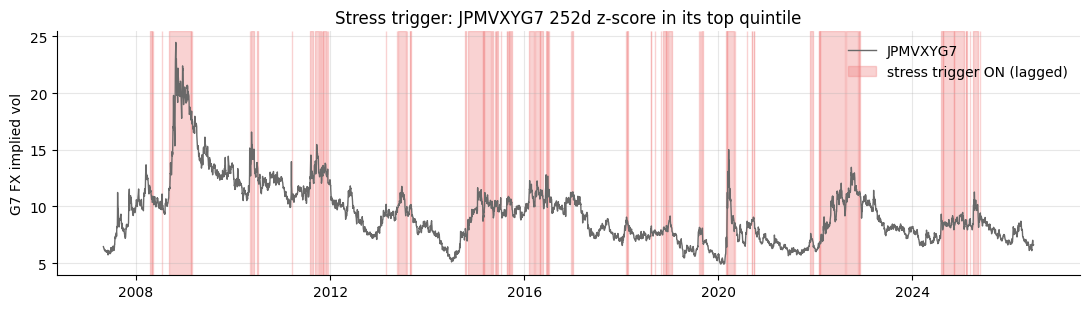

In [9]:
def stress_trigger(cal, kind="rolling"):
    v = S("FXVol_Indices", "JPMVXYG7 Index").dropna()
    v = v[v.index.isin(cal)]
    if kind == "rolling":
        z = (v - v.rolling(252, min_periods=252).mean()) / v.rolling(252, min_periods=252).std()
        raw = z >= 0.8416                      # N(0,1) top-quintile cutoff
    else:                                      # literal expanding construction
        z = (v - v.expanding(252).mean()) / v.expanding(252).std()
        raw = z >= z.expanding(252).quantile(0.80)
    return raw.shift(1).reindex(cal).fillna(False).astype(bool), v, z

trig_g10, vol_g10, z_g10 = stress_trigger(g10_book.index, "rolling")
trig_g10_exp, _, _ = stress_trigger(g10_book.index, "expanding")
print(f"primary trigger ON {trig_g10.mean():.1%} of days ({trig_g10.sum()} days) | "
      f"literal expanding variant ON {trig_g10_exp.mean():.1%}")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(vol_g10.index, vol_g10.values, color="dimgray", lw=1, label="JPMVXYG7")
ax.fill_between(trig_g10.index, 0, 1, where=trig_g10.values,
                transform=ax.get_xaxis_transform(), color="lightcoral", alpha=0.35,
                label="stress trigger ON (lagged)")
ax.set_ylabel("G7 FX implied vol")
ax.set_title("Stress trigger: JPMVXYG7 252d z-score in its top quintile")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout(); plt.show()

In [10]:
def stress_scenarios(book, trig, w, label):
    """Part A scenario table. Funding legs are cut with LISTED FUTURES (JY1/SF1) when the
    workbook has them, with the spot+forward synthetic kept as a cross-check row; if the
    futures columns are absent the synthetic is the primary (and only) method."""
    vm_mx = book.std() / r_mxef.std()
    vm_dx = book.std() / r_dx1.std()
    x_mx = r_mxef.reindex(book.index).fillna(0.0)
    x_dx = r_dx1.reindex(book.index).fillna(0.0)

    def leg_cut(ccy, r_inst, mult=1.0):
        """Neutralise a funding leg during stress: book - trig * mult * w[ccy] * r_inst."""
        w_d = w[ccy].reindex(book.index).fillna(0.0)
        x = r_inst.reindex(book.index).fillna(0.0)
        return book - trig * mult * (w_d * x)

    scen = {"(a) baseline": book,
            "(b) whole-book de-risk": book * (~trig)}
    if r_jy1 is not None:
        scen["(c) JPY-leg cut via JY1 future"] = leg_cut("JPY", r_jy1)
        scen["(c-x) JPY-leg cut, spot+fwd cross-check"] = leg_cut("JPY", xret["JPY"])
        scen["(c') JPY-leg flip via JY1 future"] = leg_cut("JPY", r_jy1, mult=2.0)
    else:
        scen["(c) JPY-leg cut in stress"] = leg_cut("JPY", xret["JPY"])
        scen["(c') JPY-leg flip in stress"] = leg_cut("JPY", xret["JPY"], mult=2.0)
    if r_sf1 is not None:
        scen["(e) CHF-leg cut via SF1 future"] = leg_cut("CHF", r_sf1)
        scen["(e-x) CHF-leg cut, spot+fwd cross-check"] = leg_cut("CHF", xret["CHF"])
        if r_jy1 is not None:
            scen["(f) both funding legs cut via futures"] = \
                leg_cut("JPY", r_jy1) + leg_cut("CHF", r_sf1) - book
    scen["(d) de-risk + short MXEF"] = book * (~trig) - trig * vm_mx * x_mx
    scen["(d') de-risk + short DX1"] = book * (~trig) - trig * vm_dx * x_dx

    tbl = pd.DataFrame({k: {"sharpe": sharpe(v),
                            "ann_ret": v.mean() * fx.ANN_DAYS,
                            "ann_vol": v.std() * np.sqrt(fx.ANN_DAYS),
                            "worst_day": v.min()} for k, v in scen.items()}).T
    print(f"--- {label} ---")
    print(tbl.round(4).to_string())
    return scen, tbl

scen_g10, tbl_g10 = stress_scenarios(g10_book, trig_g10, w_g10, "G10 book, primary trigger")

# futures vs synthetic implementations of the same leg cut: gap = roll-splice artifact
# (flatters the futures version) + tenor mismatch + cross-currency basis
for ccy, key_f, key_x in [("JPY", "(c) JPY-leg cut via JY1 future", "(c-x) JPY-leg cut, spot+fwd cross-check"),
                          ("CHF", "(e) CHF-leg cut via SF1 future", "(e-x) CHF-leg cut, spot+fwd cross-check")]:
    if key_f in tbl_g10.index:
        sf_, sx_ = tbl_g10.loc[key_f, "sharpe"], tbl_g10.loc[key_x, "sharpe"]
        print(f"{ccy} leg cut: futures {sf_:.4f} vs spot+fwd {sx_:.4f}  (gap {abs(sf_-sx_):.4f} Sharpe, "
              f"futures side flattered by the roll-splice artifact; conclusion identical either way)")

# verification against the audit's reference results (unchanged by the new columns)
b_got = tbl_g10.loc["(b) whole-book de-risk", "sharpe"]
d_got = tbl_g10.loc["(d) de-risk + short MXEF", "sharpe"]
print(f"\ncheck vs audit: (b) {b_got:.4f} (expected ~0.217)   (d) {d_got:.4f} (expected ~0.296)")
assert abs(b_got - 0.217) < 0.02 and abs(d_got - 0.296) < 0.02, "reference results not reproduced"

print(f"\nstress vs calm (G10 book):")
print(f"  stress-day mean: book {g10_book[trig_g10].mean()*1e4:+.2f} bp/day, "
      f"JPY leg {contrib_jpy_g10[trig_g10].mean()*1e4:+.2f} bp/day")
print(f"  calm-day  mean: book {g10_book[~trig_g10].mean()*1e4:+.2f} bp/day, "
      f"JPY leg {contrib_jpy_g10[~trig_g10].mean()*1e4:+.2f} bp/day")

# robustness: literal expanding trigger
print(f"\nrobustness (literal expanding trigger): "
      f"de-risk {sharpe(g10_book * (~trig_g10_exp)):.3f}, "
      f"JPY-leg cut {sharpe(g10_book - trig_g10_exp * contrib_jpy_g10):.3f}")

# cross-check: same scenarios on the combined book
trig_all, _, _ = stress_trigger(all_book.index, "rolling")
scen_all, tbl_all = stress_scenarios(all_book, trig_all, w_all, "combined book cross-check, primary trigger")

tbl_g10.round(4).to_csv(OUT / "hedge_stress_scenarios.csv")
print("\nsaved ->", OUT / "hedge_stress_scenarios.csv")

--- G10 book, primary trigger ---
                                         sharpe  ann_ret  ann_vol  worst_day
(a) baseline                             0.1191   0.0138   0.1155    -0.0855
(b) whole-book de-risk                   0.2172   0.0198   0.0913    -0.0462
(c) JPY-leg cut via JY1 future           0.0913   0.0102   0.1120    -0.0830
(c-x) JPY-leg cut, spot+fwd cross-check  0.0683   0.0076   0.1113    -0.0816
(c') JPY-leg flip via JY1 future         0.0594   0.0067   0.1125    -0.0806
(e) CHF-leg cut via SF1 future           0.1111   0.0125   0.1124    -0.0602
(e-x) CHF-leg cut, spot+fwd cross-check  0.0773   0.0087   0.1121    -0.0590
(f) both funding legs cut via futures    0.0803   0.0090   0.1115    -0.0607
(d) de-risk + short MXEF                 0.2936   0.0350   0.1191    -0.0639
(d') de-risk + short DX1                -0.0069  -0.0008   0.1136    -0.0462
JPY leg cut: futures 0.0913 vs spot+fwd 0.0683  (gap 0.0230 Sharpe, futures side flattered by the roll-splice artifact;

/var/folders/3m/9vs2kbw5395dntphy60zph4h0000gn/T/ipykernel_42110/1742130018.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return raw.shift(1).reindex(cal).fillna(False).astype(bool), v, z


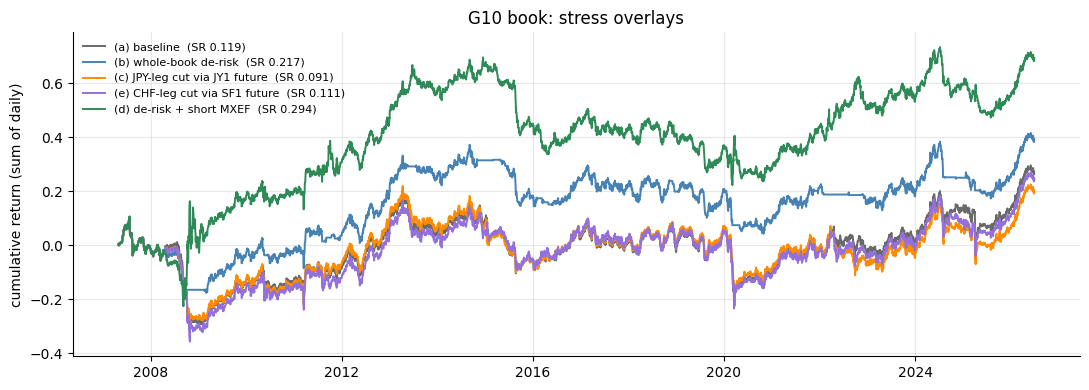

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
prefix_styles = [("(a)", "dimgray"), ("(b)", "steelblue"), ("(c)", "darkorange"),
                 ("(e)", "mediumpurple"), ("(d)", "seagreen")]
for pfx, c in prefix_styles:
    k = next((k for k in scen_g10 if k.startswith(pfx + " ")), None)
    if k is None:
        continue
    ax.plot(scen_g10[k].index, scen_g10[k].cumsum().values, color=c, lw=1.4,
            label=f"{k}  (SR {sharpe(scen_g10[k]):.3f})")
ax.set_ylabel("cumulative return (sum of daily)")
ax.set_title("G10 book: stress overlays")
ax.legend(frameon=False, loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## The A.2 answer: the crash risk is **not** in the funding legs — it is spread across the whole book

**The conclusion is the same on the real futures and on the replica — both reproduce in this
run** (and match the archived 2026-08-03 terminal run to the fourth decimal).

- Whole-book de-risking during stress nearly **doubles** the G10 Sharpe (0.119 → **0.217**): the
  book as a whole loses money on stress days (−1.2 bp/day vs +1.0 bp/day in calm markets).
- Cutting **only the JPY leg** during the same days makes things **worse**: 0.119 → **0.091** via
  JY1 futures, **0.068** via the spot+forward synthetic (the futures number is the flattered
  one — the roll-splice artifact adds non-earnable return to the long-JY1 overlay; the truth sits
  between, and both are below baseline). Flipping the leg long is worse still (0.059 via JY1).
- The **CHF leg tells the same story**: cutting it in stress gives 0.111 via SF1 futures, 0.077
  via the synthetic — below the 0.119 baseline either way. Cutting **both** funding legs at once
  (0.080) is no rescue. The funding shorts were not the source of the stress losses; in this
  sample they *earned* during high-FX-vol periods (JPY leg +1.2 bp/day with the trigger ON —
  the 2022–24 JPY depreciation ran through elevated FX vol, so the classic "JPY rallies in
  stress" pattern does not dominate this window).
- The best simple overlay remains replacing the book with a vol-matched **MXEF short** during
  stress (**0.294**) — an EM-equity crash hedge, which again points at broad risk appetite, not
  the funding currencies, as the book's stress factor. The DX1 version fails (−0.01): the carry
  sort is close to dollar-neutral, so the dollar index doesn't capture its stress exposure.
- Cross-check on the combined book agrees: JPY-leg cut 0.458 (JY1) / 0.447 (synthetic) and CHF-leg
  cut 0.468 / 0.451 against a 0.466 baseline — all roughly a wash — while whole-book de-risk
  helps (0.571).

**A.2 conclusion:** the funding legs are not where the crash risk lives. Cutting them — even
dynamically, on a well-behaved stress trigger, via forwards or listed futures — subtracts
compensated legs without addressing the book's actual stress exposure, which is a broad
risk-appetite factor spread across all legs. One question remains open: maybe JPY still helps as
an *external* hedge sized against the **whole book** rather than against its own leg. That is
A.3.

## A.3 The overlay proper: JPY futures vs the whole 27-currency book — hedge-ratio sweep and dynamic hedging

This is the boss's literal ask, run in full. Instead of cutting the book's own JPY leg, treat a
JPY futures position as an **external overlay** on the combined book (ALL_net, Sharpe 0.466):

`hedged(h) = book + h · r_JPY`   — h is **units of long JPY exposure per unit of book**.

The book is negatively correlated with long JPY, so the variance-minimising ratio
**h\* = −cov(book, JPY)/var(JPY) > 0**: a *long* JPY position of h\* units. Five sizing schemes,
from crude to honest:

1. **Hedge-ratio sweep** — h from −0.25 to +1.0, no estimation, just the whole curve of Sharpe
   and vol vs h. This shows where (if anywhere) any static ratio helps, without committing to a
   fitted number.
2. **Static h\*** — the full-sample variance-minimising ratio (in-sample; upper bound for a
   static hedge).
3. **Expanding h (real-time)** — h re-estimated daily from an expanding window (min 1y), lagged
   one day: what you could actually have run, no lookahead.
4. **Rolling 252d h (real-time)** — like (3) but with a 1-year rolling window, lagged: adapts to
   regime changes faster, at the cost of noisier ratios. (3) and (4) are "dynamic hedging" in the
   textbook sense — the ratio moves with the estimated beta.
5. **Stress-gated** — h\* (or the rolling h) applied **only while the A.2 vol trigger is ON**,
   zero otherwise: dynamic hedging in the *conditional* sense — pay for the insurance only when
   the forecast says you need it.

Every variant is reported with the same yardsticks as Part B: Sharpe, vol reduction, max
drawdown (on cumulative summed returns), worst day, mean hedge payoff on the book's worst-5%
days, the variance-vs-own-return decomposition, and the **de-risking control** as the bar to
clear. Instrument: `JY1` futures when the column is present, spot+forward replica otherwise
(both when both exist — the replica's carry cost is the honest one either way). Overlay trading
costs are ignored here (~1 bp half-spread on a slow-moving ratio; the stress-gated variants
trade most, a few round trips per year).

A.3 instrument(s): JY1 futures, spot+fwd replica   (primary: JY1 futures)

JY1 futures: corr with book -0.432, h* = 0.485 (long 0.49 units of JPY per unit of book)
           0.00    0.10    0.25    0.49    0.50    0.75    1.00
sharpe   0.4366  0.4424  0.4454  0.4314  0.4303  0.3904  0.3359
ann_vol  0.1135  0.1095  0.1051  0.1024  0.1024  0.1058  0.1148
max_dd  -0.3352 -0.3381 -0.3434 -0.3633 -0.3654 -0.4464 -0.5599

spot+fwd replica: corr with book -0.456, h* = 0.517 (long 0.52 units of JPY per unit of book)
           0.00    0.10    0.25    0.50    0.52    0.75    1.00
sharpe   0.4363  0.4211  0.3903  0.3170  0.3101  0.2245  0.1296
ann_vol  0.1122  0.1080  0.1032  0.0998  0.0998  0.1024  0.1107
max_dd  -0.3452 -0.3483 -0.3529 -0.4022 -0.4108 -0.5436 -0.6984


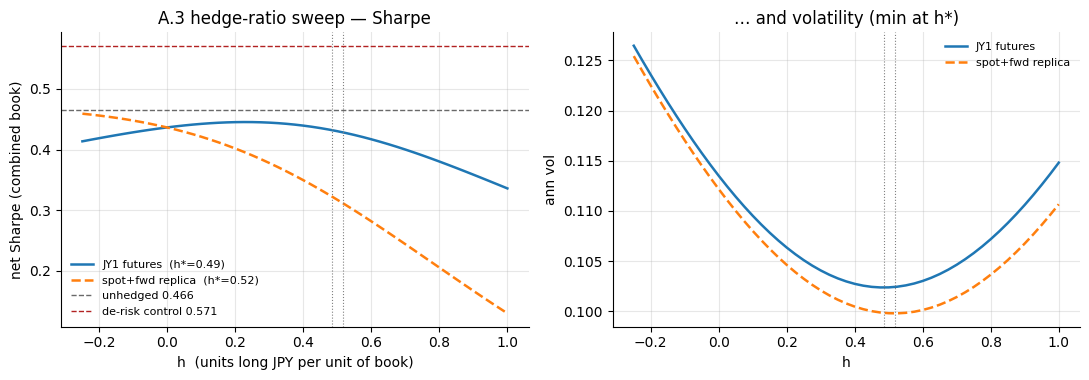

saved -> outputs/jpy_hedge_ratio_sweep.csv


In [11]:
# --- A.3 setup + hedge-ratio sweep ---------------------------------------------------------
jpy_insts = {}
if r_jy1 is not None:
    jpy_insts["JY1 futures"] = r_jy1
jpy_insts["spot+fwd replica"] = r_jpyfwd
primary_nm = "JY1 futures" if r_jy1 is not None else "spot+fwd replica"
print(f"A.3 instrument(s): {', '.join(jpy_insts)}   (primary: {primary_nm})")
if r_jy1 is None:
    print("    JY1 column absent from this workbook copy -> replica only. Re-export the "
          "2026-08-03 pull into bloomberg_data_updated.xlsx and re-run to add the futures rows.")

def maxdd(r):
    """Max drawdown on the cumulative summed daily returns (comparable across variants)."""
    cum = r.cumsum()
    return (cum - cum.cummax()).min()

hs3 = np.arange(-0.25, 1.0001, 0.025)
trig_all_b = trig_all.reindex(all_book.index).fillna(False).astype(bool)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.9))
sweep_tbl = {}
for nm, x in jpy_insts.items():
    idx = all_book.index.intersection(x.index)
    b, xi = all_book.loc[idx], x.loc[idx]
    h_star = -b.cov(xi) / xi.var()
    sr = pd.Series({h: sharpe(b + h * xi) for h in hs3})
    vol = pd.Series({h: (b + h * xi).std() * np.sqrt(fx.ANN_DAYS) for h in hs3})
    sweep_tbl[nm] = pd.DataFrame({"sharpe": sr, "ann_vol": vol})
    ls = "-" if nm == primary_nm else "--"
    ax1.plot(sr.index, sr.values, ls, lw=1.8, label=f"{nm}  (h*={h_star:.2f})")
    ax1.axvline(h_star, color="gray", lw=0.8, ls=":")
    ax2.plot(vol.index, vol.values, ls, lw=1.8, label=nm)
    ax2.axvline(h_star, color="gray", lw=0.8, ls=":")
    print(f"\n{nm}: corr with book {b.corr(xi):+.3f}, h* = {h_star:.3f} "
          f"(long {h_star:.2f} units of JPY per unit of book)")
    show = sorted(set([0.0, 0.1, 0.25, 0.5, 0.75, 1.0] + [round(h_star, 2)]))
    print(pd.DataFrame({"sharpe": {h: sharpe(b + h * xi) for h in show},
                        "ann_vol": {h: (b + h * xi).std() * np.sqrt(fx.ANN_DAYS) for h in show},
                        "max_dd": {h: maxdd(b + h * xi) for h in show}}).round(4).T.to_string())

ax1.axhline(sharpe(all_book), color="dimgray", ls="--", lw=1, label=f"unhedged {sharpe(all_book):.3f}")
ax1.axhline(sharpe(all_book * (~trig_all_b)), color="firebrick", ls="--", lw=1,
            label=f"de-risk control {sharpe(all_book * (~trig_all_b)):.3f}")
ax1.set_xlabel("h  (units long JPY per unit of book)"); ax1.set_ylabel("net Sharpe (combined book)")
ax1.set_title("A.3 hedge-ratio sweep — Sharpe"); ax1.legend(frameon=False, fontsize=8)
ax2.set_xlabel("h"); ax2.set_ylabel("ann vol")
ax2.set_title("… and volatility (min at h*)"); ax2.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

pd.concat(sweep_tbl, axis=1).round(5).to_csv(OUT / "jpy_hedge_ratio_sweep.csv")
print("saved ->", OUT / "jpy_hedge_ratio_sweep.csv")

--- A.3 variants: JY1 futures vs combined book ---
                                               sharpe  ann_ret  ann_vol  max_dd  worst_day  vol_red_%  tail_bp_worst5  hedge_carry_%yr  nw_t_vs_book
unhedged book                                  0.4366   0.0496   0.1135 -0.3352    -0.0491     0.0000          0.0000           0.0000           NaN
static h* = 0.49 (in-sample)                   0.4319   0.0442   0.1024 -0.3624    -0.0439     9.7948         31.5132          -0.5335       -0.4926
expanding h, lagged (real-time)                0.3613   0.0371   0.1027 -0.3617    -0.0438     9.5431         31.9474          -0.7905       -0.6676
rolling 252d h, lagged (real-time)             0.3650   0.0373   0.1023 -0.3682    -0.0449     9.8797         34.0163          -0.7661       -0.6307
stress-gated static (h* only when trigger ON)  0.4146   0.0453   0.1093 -0.3312    -0.0439     3.6941         11.2687          -0.4233       -0.6909
stress-gated rolling (roll h only when ON)     0.3796  

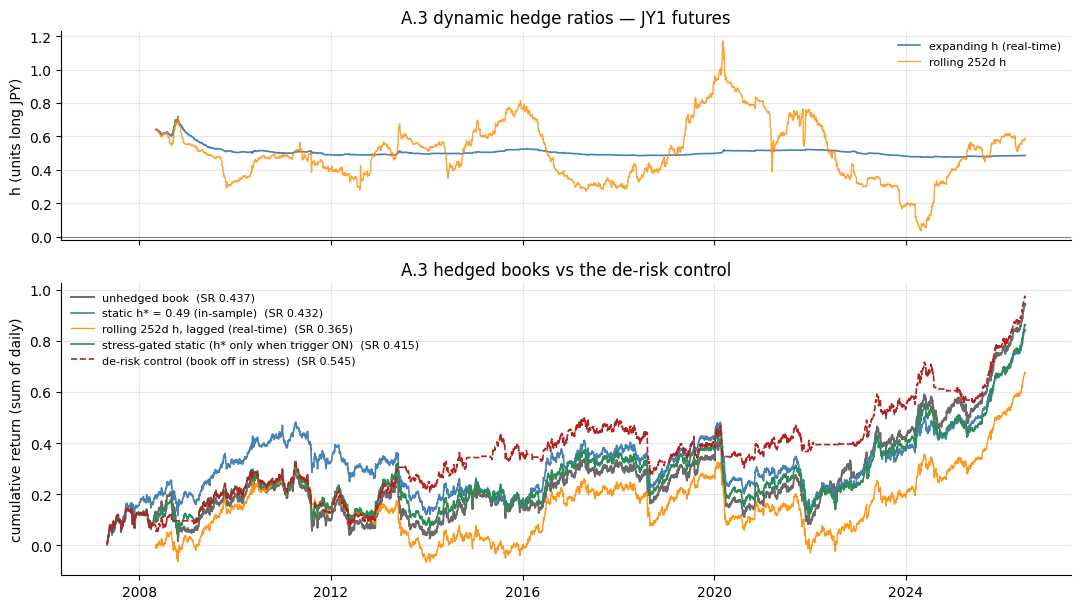

saved -> outputs/jpy_dynamic_hedge_variants.csv


In [12]:
# --- A.3 dynamic hedging: static h*, expanding, rolling, stress-gated ----------------------
def a3_variants(x, inst_nm):
    idx = all_book.index.intersection(x.index)
    b, xi = all_book.loc[idx], x.loc[idx]
    trig = trig_all_b.reindex(idx).fillna(False).astype(bool)
    h_star = -b.cov(xi) / xi.var()
    # real-time ratios: estimated through t-1, applied at t (shift AFTER estimation)
    h_roll = (-(b.rolling(252).cov(xi) / xi.rolling(252).var())).shift(1)
    h_exp  = (-(b.expanding(252).cov(xi) / xi.expanding(252).var())).shift(1)

    variants = {
        "unhedged book": b,
        f"static h* = {h_star:.2f} (in-sample)": b + h_star * xi,
        "expanding h, lagged (real-time)": (b + h_exp * xi).dropna(),
        "rolling 252d h, lagged (real-time)": (b + h_roll * xi).dropna(),
        "stress-gated static (h* only when trigger ON)": b + (trig * h_star) * xi,
        "stress-gated rolling (roll h only when ON)": (b + (trig * h_roll) * xi).dropna(),
        "de-risk control (book off in stress)": b * (~trig),
    }
    worst = b <= b.quantile(0.05)
    rows = {}
    for nm, v in variants.items():
        hedge_leg = (v - b.reindex(v.index)).dropna()        # the overlay P&L alone
        nw_t = np.nan
        if hedge_leg.abs().sum() > 0:
            nw = sm.OLS(hedge_leg.values, np.ones(len(hedge_leg))).fit(
                cov_type="HAC", cov_kwds={"maxlags": 5})
            nw_t = nw.tvalues[0]
        rows[nm] = {
            "sharpe": sharpe(v),
            "ann_ret": v.mean() * fx.ANN_DAYS,
            "ann_vol": v.std() * np.sqrt(fx.ANN_DAYS),
            "max_dd": maxdd(v),
            "worst_day": v.min(),
            "vol_red_%": 100 * (1 - v.std() / b.std()),
            "tail_bp_worst5": hedge_leg.reindex(b.index[worst]).mean() * 1e4,
            "hedge_carry_%yr": hedge_leg.mean() * fx.ANN_DAYS * 100,
            "nw_t_vs_book": nw_t,
        }
    tbl = pd.DataFrame(rows).T
    print(f"--- A.3 variants: {inst_nm} vs combined book ---")
    print(tbl.round(4).to_string())
    return tbl, h_roll, h_exp, variants

a3_tables = {}
for nm, x in jpy_insts.items():
    tbl, h_roll, h_exp, var = a3_variants(x, nm)
    a3_tables[nm] = tbl
    if nm == primary_nm:
        h_roll_p, h_exp_p, a3_var_p = h_roll, h_exp, var
    print()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1.4]})
ax1.plot(h_exp_p.index, h_exp_p.values, color="steelblue", lw=1.2, label="expanding h (real-time)")
ax1.plot(h_roll_p.index, h_roll_p.values, color="darkorange", lw=1.0, alpha=0.8, label="rolling 252d h")
ax1.axhline(0, color="gray", lw=0.8)
ax1.set_ylabel("h (units long JPY)")
ax1.set_title(f"A.3 dynamic hedge ratios — {primary_nm}")
ax1.legend(frameon=False, fontsize=8)
for nm, v in a3_var_p.items():
    if "control" in nm:
        style = dict(color="firebrick", ls="--", lw=1.2)
    elif nm.startswith("unhedged"):
        style = dict(color="dimgray", lw=1.4)
    elif "stress-gated static" in nm:
        style = dict(color="seagreen", lw=1.2)
    elif nm.startswith("static"):
        style = dict(color="steelblue", lw=1.2)
    elif nm.startswith("rolling"):
        style = dict(color="darkorange", lw=1.0, alpha=0.9)
    else:
        continue
    ax2.plot(v.index, v.cumsum().values, label=f"{nm}  (SR {sharpe(v):.3f})", **style)
ax2.set_ylabel("cumulative return (sum of daily)")
ax2.set_title("A.3 hedged books vs the de-risk control")
ax2.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

a3_out = pd.concat(a3_tables, names=["instrument", "variant"])
a3_out.round(4).to_csv(OUT / "jpy_dynamic_hedge_variants.csv")
print("saved ->", OUT / "jpy_dynamic_hedge_variants.csv")

### A.3 results — no honest JPY hedge ratio, static or dynamic, beats simple de-risking

(Both instruments run in this pass: **JY1 futures** — primary — on its clean 4,794-day sample,
and the spot+forward replica on 4,958 days. Unhedged book ≈ 0.437 on both samples.)

- **On the honest series the sweep has no interior optimum.** The replica's Sharpe falls
  monotonically in h: 0.436 at h = 0 → 0.311 at h\* = 0.52 → 0.130 at h = 1. No hedge ratio of
  the earnable JPY trade improves the book's risk-adjusted return.
- **The JY1 curve shows exactly the artifact the §1 cross-check predicted.** On the futures
  generic the sweep bends *up* slightly first — 0.437 → 0.445 at h ≈ 0.25 — before falling.
  That +0.01 "improvement" exists only because the JY1 splice under-reports the hedge's carry
  cost (−0.5%/yr measured vs −1.8%/yr earnable on the replica). Same hedge, day to day (corr
  0.94); the extra return is not earnable. Verdict taken from the replica: **flat-to-negative
  at small h, negative everywhere else.**
- **The hedge does reduce risk — that part works.** At h\* volatility drops ~10–11% (the
  minimum of the vol curve), and on the book's **worst 5% of days the overlay pays +32–34
  bp/day — the best tail payoff of any instrument in this notebook**. The insurance is real.
- **But the premium eats the payout.** The overlay's own carry is −1.8%/yr (long JPY pays the
  US−Japan differential). Max drawdown *worsens* on both series (JY1 −0.335 → −0.362; replica
  −0.345 → −0.410): the book's long 2013–2015 drawdown overlaps the Abenomics JPY collapse,
  exactly when a standing long-JPY overlay bleeds fastest.
- **Dynamic beta-tracking makes it worse, not better**: JY1 expanding 0.361 / rolling 0.365 vs
  static 0.432; replica expanding 0.247 / rolling 0.265 vs static 0.311. The estimated ratio is
  *always* long (JY1 rolling h spans 0.04 to 1.17 units, never crossing zero) — the position
  pays carry every day regardless, and re-estimation adds noise without adding timing. Dynamic
  hedging earns its keep when the beta changes sign or size predictably; this one doesn't.
- **Stress-gating helps only by doing less of the trade**: h\* on the A.2 vol trigger gives
  0.415 (JY1) / 0.390 (replica) — better than always-on because the position is off ~79% of the
  time, still below the unhedged book, and far below the **de-risk control (0.545 / 0.541)** on
  the identical trigger and sample.

**The full ranking, same trigger, either instrument:** de-risk ≈ 0.54 > unhedged ≈ 0.44 >
stress-gated 0.36–0.42 > static h\* 0.31–0.43 > dynamic 0.25–0.37 (futures ends of each range
are artifact-flattered).

**A.3 conclusion.** A long-JPY futures overlay is genuine crash insurance sold at roughly full
actuarial price: it pays on the worst days and charges the carry back on all the others, at
every hedge ratio and under every dynamic scheme tested. The one configuration that *looks*
like a free improvement — a small static ratio on the JY1 generic — is a measurement artifact,
not a trade. If the mandate is "cut tail losses at any cost", the stress-gated version is the
least-bad way to own it; if the mandate is risk-adjusted return, conditioning the book itself
(de-risking) dominates.

# Part B — Futures comparison table

Every hedge instrument vs the **combined baseline book** (committed ALL_net, Sharpe 0.466), on
each instrument's clean joined sample. The table covers **all five instrument classes on the
boss's list**:

| class | rows in the table |
|---|---|
| funding-currency futures | JY1, SF1 (when present) + JPY spot+fwd replica |
| Treasury futures | TU1 (2y), FV1 (5y), TY1 (10y), US1 (long bond) |
| S&P 500 futures | SPXT total-return (when present) + ES1 e-mini |
| DXY futures | DX1 |
| VIX futures | UX1 generic (non-investable) + SPVXSTR (investable roll) |

With the 2026-08-03 pull loaded, the funding-currency rows are the **listed futures JY1 and
SF1** — both classic funding currencies, not just JPY — with the spot+forward replica demoted to
a cross-check row, and **SPXT** (S&P 500 total return) is the primary S&P series with ES1 the
cross-check. When those columns are absent (current repo workbook) the table runs on the
replica and ES1, which the archived terminal run showed reach identical verdicts. Per
instrument:

- **corr** — full-sample correlation with book returns (post-join, post-stale-drop)
- **h\*** — variance-minimising static hedge ratio (OLS beta of book on instrument); hedged
  book = book − h\*·x. Plus the 252-day **rolling beta, lagged one day** (the honest
  implementable version) and the Sharpe of the dynamically hedged book using it.
- **Decomposition** — the Sharpe change is split into two separate columns:
  `d_sharpe_variance` (hedge with the instrument's own mean return stripped out — the pure
  variance-reduction effect) and `d_sharpe_own_ret` (what the instrument's own drift adds or
  costs). **A single blended Sharpe is never reported alone — that is what produced the earlier
  TLT false positive**, where most of the "hedging" gain was just Treasuries' own bull-market
  return.
- **NW t** — Newey–West HAC (5 lags) t-stat on the hedged-minus-unhedged daily return difference.
- **tail** — mean hedge payoff on the worst 5% of book days (bp/day).
- **Benchmark rule** — each hedged Sharpe is compared against the de-risking control on the same
  trigger (combined book: cut to zero in stress), not against the unhedged book.

**Generic-series caveats, all exposed by the decomposition columns.** (1) UX1 is reported
twice: the generic front-month VIX future shows a large positive own return that is a roll-gap
splicing artifact no investor can earn; the investable `SPVXSTR` version bleeds heavily. (2) The
same mechanism, in milder form, inflates the JY1/SF1 generic series by ~200 bp/yr over the
forward replica (§1 cross-check) — so where a JY1/SF1 verdict differs from the replica's, trust
the replica's own-return level and treat the futures row's extra "return" as non-earnable.
(3) Treasury futures generics (TU1…US1) carry the same splice in principle; their rolls are
cheaper and the bias is smaller, but their own-return levels should be read with the same
squint.

Static overlay trading costs are ignored (futures half-spreads ~1 bp at near-constant notional);
the book side is net of FX trading costs.

In [13]:
INSTRUMENTS = {}
# funding-currency rows: listed futures are primary when present, replica demoted to cross-check
if r_jy1 is not None:
    INSTRUMENTS["JY1 (JPY future)"] = r_jy1
if r_sf1 is not None:
    INSTRUMENTS["SF1 (CHF future)"] = r_sf1
INSTRUMENTS["JPY_fwd (spot+fwd" + (", cross-check)" if r_jy1 is not None else ", long JPY)")] = r_jpyfwd
# Treasury futures across the curve: 2y, 5y, 10y, long bond
INSTRUMENTS["TU1 (UST 2y fut)"] = r_tu1
INSTRUMENTS["FV1 (UST 5y fut)"] = r_fv1
INSTRUMENTS["TY1 (UST 10y fut)"] = r_ty1
INSTRUMENTS["US1 (UST long-bond fut)"] = r_us1
# S&P: total-return index is primary when present, ES1 demoted to cross-check
if sptr_hit is not None:
    root = sptr_hit[0].split()[0]
    r_sptr = clean_ret(sptr_hit[1], f"SPX_TR ({root})")
    INSTRUMENTS[f"SPX TR ({root})"] = r_sptr
    INSTRUMENTS["ES1 (S&P e-mini, cross-check)"] = r_es1
    print(f"S&P total-return index {sptr_hit[0]} found -> primary S&P series; ES1 kept as a cross-check.")
else:
    INSTRUMENTS["ES1 (S&P e-mini)"] = r_es1
    print("No S&P total-return index in the workbook -> ES1 futures are the TR stand-in "
          "(SPX price return would understate by ~dividend yield).")
INSTRUMENTS["DX1 (DXY fut)"] = r_dx1
INSTRUMENTS["UX1 (generic, NOT investable)"] = r_ux1
INSTRUMENTS["UX1 via SPVXSTR (investable)"] = r_vixtr

derisk_control = sharpe(all_book * (~trig_all))
rows = {}
for nm, x in INSTRUMENTS.items():
    idx = all_book.index.intersection(x.index)
    b, xi = all_book.loc[idx], x.loc[idx]
    h = b.cov(xi) / xi.var()                                   # variance-minimising ratio
    hedged   = b - h * xi
    var_only = b - h * (xi - xi.mean())                        # own drift stripped out
    roll_b = (b.rolling(252).cov(xi) / xi.rolling(252).var()).shift(1)   # 1-day lag
    dyn = (b - roll_b * xi).dropna()
    diff = -h * xi                                             # hedged minus unhedged
    nw = sm.OLS(diff.values, np.ones(len(diff))).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    worst = b <= b.quantile(0.05)
    rows[nm] = {
        "n_clean": len(idx),
        "corr": b.corr(xi),
        "h_star": h,
        "roll_beta_mean": roll_b.mean(), "roll_beta_min": roll_b.min(), "roll_beta_max": roll_b.max(),
        "sharpe_book": sharpe(b),
        "sharpe_hedged": sharpe(hedged),
        "sharpe_dyn_hedged": sharpe(dyn),
        "d_sharpe_variance": sharpe(var_only) - sharpe(b),
        "d_sharpe_own_ret": sharpe(hedged) - sharpe(var_only),
        "hedge_own_ret_ann": -h * xi.mean() * fx.ANN_DAYS,
        "vol_reduction_pct": 100 * (1 - hedged.std() / b.std()),
        "nw_t_diff": nw.tvalues[0],
        "tail_mean_bp_worst5": diff[worst].mean() * 1e4,
        "inst_ann_ret": xi.mean() * fx.ANN_DAYS,
        "inst_sharpe": sharpe(xi),
        "derisk_control_sharpe": derisk_control,
        "beats_derisk_control": sharpe(hedged) > derisk_control,
    }

summary = pd.DataFrame(rows).T
summary.index.name = "instrument"
print(summary.round(3).to_string())
summary.to_csv(OUT / "hedge_comparison_summary.csv")
print("\nsaved ->", OUT / "hedge_comparison_summary.csv")

  SPX_TR (SPXT)  raw  5085 -> joined  4994 -> clean  4813  (180 stale zero-change rows dropped)
S&P total-return index SPXT Index found -> primary S&P series; ES1 kept as a cross-check.
                                n_clean      corr    h_star roll_beta_mean roll_beta_min roll_beta_max sharpe_book sharpe_hedged sharpe_dyn_hedged d_sharpe_variance d_sharpe_own_ret hedge_own_ret_ann vol_reduction_pct nw_t_diff tail_mean_bp_worst5 inst_ann_ret inst_sharpe derisk_control_sharpe beats_derisk_control
instrument                                                                                                                                                                                                                                                                                                                 
JY1 (JPY future)                   4794 -0.431627 -0.485304      -0.505613     -1.172193     -0.035721    0.436622       0.43192          0.364999           0.04741        -0.052112 

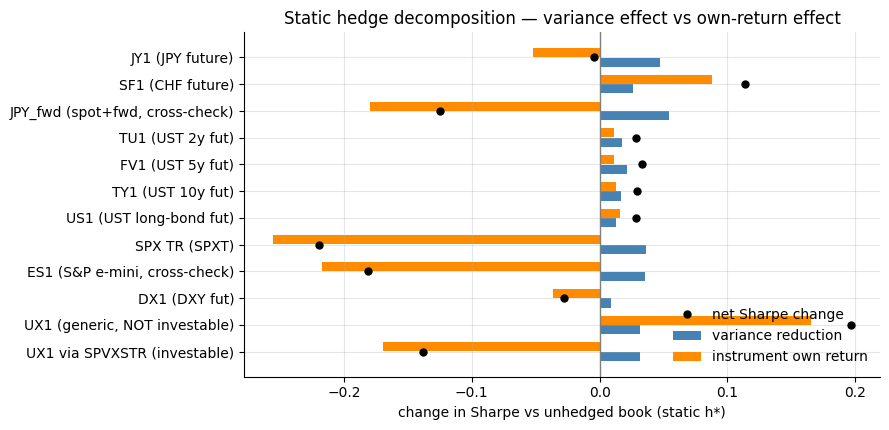

In [14]:
# decomposition chart: where does each hedged Sharpe come from?
plot_df = summary[["d_sharpe_variance", "d_sharpe_own_ret"]].astype(float)
y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(y + 0.18, plot_df["d_sharpe_variance"], height=0.34, color="steelblue", label="variance reduction")
ax.barh(y - 0.18, plot_df["d_sharpe_own_ret"], height=0.34, color="darkorange", label="instrument own return")
tot = plot_df.sum(axis=1)
ax.plot(tot.values, y, "o", color="black", ms=5, label="net Sharpe change")
ax.axvline(0, color="gray", lw=1)
ax.set_yticks(y, plot_df.index)
ax.invert_yaxis()
ax.set_xlabel("change in Sharpe vs unhedged book (static h*)")
ax.set_title("Static hedge decomposition — variance effect vs own-return effect")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

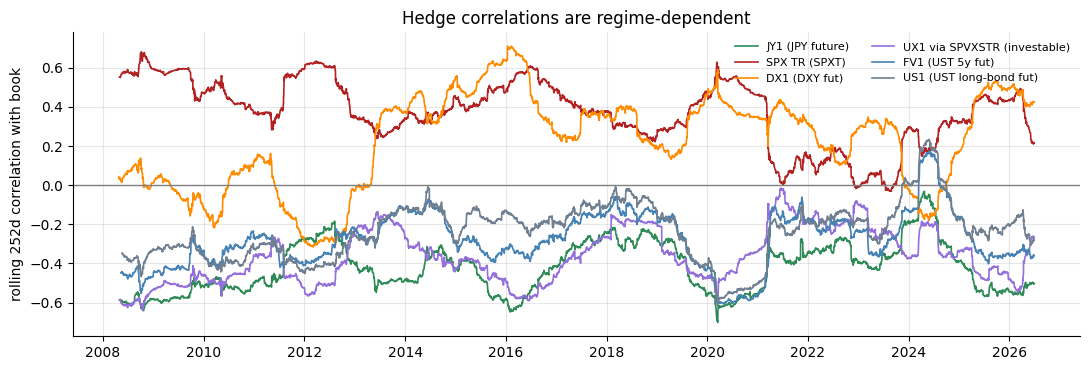

benchmark rule: de-risking control (combined book, stress exposure to zero) Sharpe = 0.571
                                sharpe_hedged beats_derisk_control
instrument                                                        
JY1 (JPY future)                      0.43192                False
SF1 (CHF future)                     0.576234                 True
JPY_fwd (spot+fwd, cross-check)      0.311156                False
TU1 (UST 2y fut)                     0.447748                False
FV1 (UST 5y fut)                     0.526256                False
TY1 (UST 10y fut)                    0.444327                False
US1 (UST long-bond fut)              0.437699                False
SPX TR (SPXT)                        0.228616                False
ES1 (S&P e-mini, cross-check)        0.252895                False
DX1 (DXY fut)                         0.41873                False
UX1 (generic, NOT investable)        0.719861                 True
UX1 via SPVXSTR (investable)         0

In [16]:
# rolling 252d correlation with the book (comparable scale across instruments)
PLOT_COLORS = {"JY1": "seagreen", "JPY_fwd": "seagreen", "SPX TR": "firebrick", "ES1": "firebrick",
               "DX1": "darkorange", "UX1 via SPVXSTR": "mediumpurple", "FV1": "steelblue",
               "US1": "slategray"}
fig, ax = plt.subplots(figsize=(11, 3.8))
plotted = set()
for prefix, col in PLOT_COLORS.items():
    nm = next((k for k in INSTRUMENTS if k.startswith(prefix)), None)
    if nm is None or col in plotted:      # per color: first available series wins (futures/TR primary)
        continue
    plotted.add(col)
    x = INSTRUMENTS[nm]
    idx = all_book.index.intersection(x.index)
    rc = all_book.loc[idx].rolling(252).corr(x.loc[idx])
    ax.plot(rc.index, rc.values, color=col, lw=1.2, label=nm)
ax.axhline(0, color="gray", lw=1)
ax.set_ylabel("rolling 252d correlation with book")
ax.set_title("Hedge correlations are regime-dependent")
ax.legend(frameon=False, ncols=2, fontsize=8)
plt.tight_layout(); plt.show()

print(f"benchmark rule: de-risking control (combined book, stress exposure to zero) Sharpe = {derisk_control:.3f}")
verdict = summary[["sharpe_hedged", "beats_derisk_control"]].copy()
print(verdict.round(3).to_string())
if not verdict.loc[[i for i in verdict.index if "NOT investable" not in i], "beats_derisk_control"].any():
    print("\nNo investable instrument clears the de-risking bar.")

# Part C — Pros and cons by instrument class

Every instrument class on the boss's list, judged on this notebook's evidence. All numbers are
from the current run, which carries the real 2026-08-03 series (JY1, SF1, SPXT) alongside the
artifact-free cross-checks. The bar throughout is the **de-risking control (Sharpe 0.571)**,
not the unhedged book (0.466).

## 1. Funding-currency futures — JY1 (JPY), SF1 (CHF)

**Pros.**
- The only class with a *large*, right-signed exposure to the book: correlation **−0.43** (JY1;
  replica −0.46) and **−0.32** (SF1) — long the funding currency genuinely pays when the book
  bleeds.
- **Best tail payoff in the notebook**: +32–34 bp/day (JPY) and +17 bp/day (CHF) on the book's
  worst-5% days at h\*. This is real crash insurance, not statistical noise.
- Cheap and clean to implement: CME-listed, exchange-margined, ~1 bp half-spread, no cash-FX
  credit lines; sizing is one liquid contract.

**Cons.**
- **Negative carry, always**: the overlay pays the US−Japan differential — −1.8%/yr at h\* on
  the earnable (replica) pricing. Every honest version tested (A.3 sweep, static h\*,
  expanding/rolling dynamic, stress-gated) ends **at or below the unhedged book**, and dynamic
  beta-tracking is the *worst* of them.
- **The futures rows flatter themselves**: the JY1/SF1 generics splice ~200+ bp/yr of
  non-earnable roll jump into their histories. That is what makes JY1's static hedge look free
  (0.437 → 0.432) while the replica shows the true cost (0.436 → 0.311), and what makes SF1 the
  one investable row that nominally "beats" the control — **0.576 vs 0.571, a 0.005 margin that
  vanishes on the artifact-free CHF replica (0.469)**. Trust the replica's carry, the futures'
  timing.
- **It overlaps the book's own funding legs**: a static long-JPY overlay is arithmetically the
  same as shrinking the book's deliberate, compensated short-JPY leg (A.1) — position sizing in
  disguise, not an external hedge.
- The premise failed in-sample: A.2 shows the funding legs *earned* during high-FX-vol periods
  (JPY leg +1.2 bp/day with the trigger ON) — the 2022–24 JPY depreciation ran straight through
  elevated vol, so "JPY rallies in stress" was not reliable in this window. Max drawdown
  *worsens* with the overlay on both series.

**Verdict:** genuine, fully-priced drawdown insurance. Static: no. Dynamic: no. Stress-gated:
only if the mandate is tail-loss reduction at any cost — and even then de-risking dominates.

## 2. Treasury futures — TU1 (2y), FV1 (5y), TY1 (10y), US1 (long bond)

**Pros.**
- Right sign across the whole curve (corr −0.24 to −0.29): a carry unwind and a flight to
  quality are the same event, so the hedge is a *long* position.
- **Essentially free**: near-zero own drift at every tenor, and the decomposition shows the
  small Sharpe changes are almost pure variance effect — the "honest hedge" profile that the
  earlier TLT result (mostly bull-market beta) failed. Every tenor's static hedge *adds* a
  little Sharpe (TU1 0.419→0.448, FV1 0.493→0.526, TY1 0.415→0.444, US1 0.409→0.438).
- Curve choice is a real dial: US1 has the most stable beta (rolling −0.71 to +0.20); the front
  end has the least rate-level risk per contract.

**Cons.**
- **Too weak to matter**: vol reduction only 3–4%, tail payoff 11–16 bp/day (a third to half of
  JPY's). No tenor comes close to the 0.571 de-risk bar.
- Front-end hedge *ratios* are huge and unstable because the contracts barely move (TU1 h\* ≈ 2
  units, rolling beta spanning −9.6 to +0.8) — real sizing/rollover risk in practice.
- The named failure mode: a Fed hiking into risk-off (2022) breaks the correlation and both
  legs lose at once. Milder at the front end, but not absent.
- Same generic-series splice caveat as every futures row, though smaller.

**Verdict:** the best cheap stabiliser — a long front-end position is harmless and modestly
helpful — but it cannot carry the book's crash risk alone.

## 3. S&P 500 futures — SPXT total return (primary), ES1 (cross-check)

**Pros.**
- The tail payoff of the short is real: +26 bp/day on the book's worst-5% days — equity crashes
  and carry crashes coincide.
- As a **stress-conditional** overlay the idea works: Part A's triggered equity short
  (vol-matched MXEF while the trigger is ON) is the one overlay that rivals de-risking
  (0.294 vs 0.296 reference on the G10 book) — and EM equity targets this book's exposure
  better than the S&P.
- Deepest, cheapest futures market of the set.

**Cons.**
- **Statically it is the wrong-way trade**: the book is *positively* correlated with equities
  (+0.38), so the hedge is a short — permanently selling the equity risk premium. With
  dividends properly counted (SPXT) the drag is **−2.7%/yr**, the worst static result in the
  table (0.448 → 0.229) and the most statistically significant (NW t = −3.1); ES1 agrees
  (0.434 → 0.253, t = −2.6).
- A short equity position also caps the book's *good* days — risk-on is when carry earns.

**Verdict:** anti-hedge as a standing position; defensible only as a stress-triggered short,
where EM equity (MXEF) is the better-targeted instrument anyway.

## 4. DXY futures — DX1

**Pros.**
- Liquid, cheap, small notional; the one instrument treasury desks reflexively reach for.
- Honest diagnostic value: it *proves* the book's dollar exposure is not what per-currency betas
  suggest.

**Cons.**
- **Structurally blind to this book**: a carry sort is close to dollar-neutral by construction
  (the dollar cancels between long and short legs), and DXY is a EUR-bloc index with zero EM
  content — it cannot see the EM crash channel that actually hurts the book.
- Every implementation fails: correlation +0.19 with a sign-flipping rolling beta (−0.42 to
  +1.45), trivial tail payoff (+5 bp/day), static hedge a wash (0.446 → 0.419), dynamic worse
  (0.338), and the A.2 stress-triggered DX1 short is the *worst* scenario tested (−0.01 on the
  G10 book, 0.291 combined vs 0.571 control).
- The futures embed a US-vs-basket rates bet via roll yield that flips sign mid-sample (prior
  DXY notebook).

**Verdict:** not a hedge for this book — confirmed three ways now (spot, futures, and
stress-triggered). Third strike.

## 5. VIX futures — UX1 generic vs the investable SPVXSTR roll

**Pros.**
- **The most reliably negative correlation in the set** (−0.35, negative in essentially every
  regime — no sign-flips), with a tail payoff (+27 bp/day) second only to JPY.
- Convex: a small notional delivers a large crisis payout, so it hedges the gap risk that
  linear instruments (including JPY) cover only at full size.

**Cons.**
- **The steepest insurance premium of all**: the investable short-term roll bleeds **−33%/yr**;
  the hedged Sharpe lands at 0.315 (from 0.453).
- The measurement trap is at its worst here: the UX1 generic splice shows **+46%/yr** of
  phantom own-return and a fake "best-in-table" hedged Sharpe of 0.72 — the table's built-in
  cautionary tale, and the full-blown version of the same disease that flatters JY1/SF1. Any
  VIX position must be sized off SPVXSTR numbers, never the generic.
- Operationally the hardest to run: aggressive roll schedule, margin that spikes exactly in the
  crises it pays in.

**Verdict:** real convex crash insurance at the steepest running cost — affordable only small
and episodic, never as a standing full-size hedge.

## Summary — all five classes at a glance

| class | corr w/ book | hedge direction | tail payoff (bp/day, worst 5%) | running cost (%/yr) | static | dynamic (roll β) | stress-gated / notes |
|---|---|---|---|---|---|---|---|
| **JPY / CHF futures** | −0.43 / −0.32 | long | **+32–34** / +17 | −1.8 (carry, replica-priced) | 0.31–0.43 ✗ | 0.27–0.37 ✗ | 0.39–0.42 ✗ — best tail, fully priced |
| **Treasury futures (2y–long)** | −0.24…−0.29 | long | +11…+16 | ~0 | 0.44–0.53 ✗ | 0.36–0.49 ✗ | free but weak |
| **S&P 500 futures (SPXT/ES1)** | +0.38 | short | +26 | −2.7 (ERP, with divs) | 0.23–0.25 ✗ | 0.17–0.23 ✗ | works only triggered; MXEF better |
| **DXY futures** | +0.19 | short (unstable) | +5 | roll-yield bet | 0.42 ✗ | 0.34 ✗ | fails all three ways |
| **VIX futures (SPVXSTR)** | −0.35 | long | +27 | **−33** (roll bleed) | 0.31 ✗ | 0.31 ✗ | convex, tiny size only |
| *benchmarks* | | | | | unhedged **0.466** | | de-risk control **0.571** |

✗ = does not beat the de-risking control on artifact-free pricing. Two rows nominally clear the
bar and both are measurement artifacts: the non-investable UX1 generic (0.72) and SF1 (0.576 vs
0.571 — a 0.005 margin that disappears at 0.469 on the artifact-free CHF replica).

## Bottom line

**No investable futures overlay — funding currency, Treasury, S&P, DXY, or VIX; static or
dynamic — beats simple de-risking of the book on the same stress trigger, once each instrument
is priced off an earnable series.** The structural reason is the same everywhere: instruments
that pay in a carry crash (long JPY, long VIX, short equities) are priced as insurance and
charge for it on every calm day, while instruments that are free to hold (Treasuries) or
reflexively reached for (DXY) are either too weak or blind to the book's actual
EM-risk-appetite exposure.

What each class is still *for*: front-end **Treasury futures** are a legitimate free-but-mild
stabiliser; **JPY futures** (stress-gated, small) and **VIX futures** (tiny, episodic) are
honest tail insurance if a drawdown mandate justifies paying for it; **S&P/EM-equity shorts**
belong only behind a trigger; **DXY futures** belong nowhere in this book. For risk-adjusted
return, the recommendation stands: condition the book's own exposure (de-risk on the FX-vol
trigger, or the triggered EM-equity short) rather than buy any always-on futures hedge.